Cell 1: imports


In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [2]:
DATA_PATH = "insurance.csv"
DOCS_DIR = Path("docs")
DOCS_DIR.mkdir(exist_ok=True)

df = pd.read_csv(DATA_PATH)
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
required_columns = {"age", "sex", "bmi", "children", "smoker", "region", "charges"}
missing = required_columns - set(df.columns)

if missing:
    raise ValueError(f"Missing required columns: {missing}")

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing values:\n", df.isna().sum())
print("\nData types:\n", df.dtypes)
print("\nDescribe:\n", df.describe())

Shape: (1338, 7)

Columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

Missing values:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Data types:
 age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

Describe:
                age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010


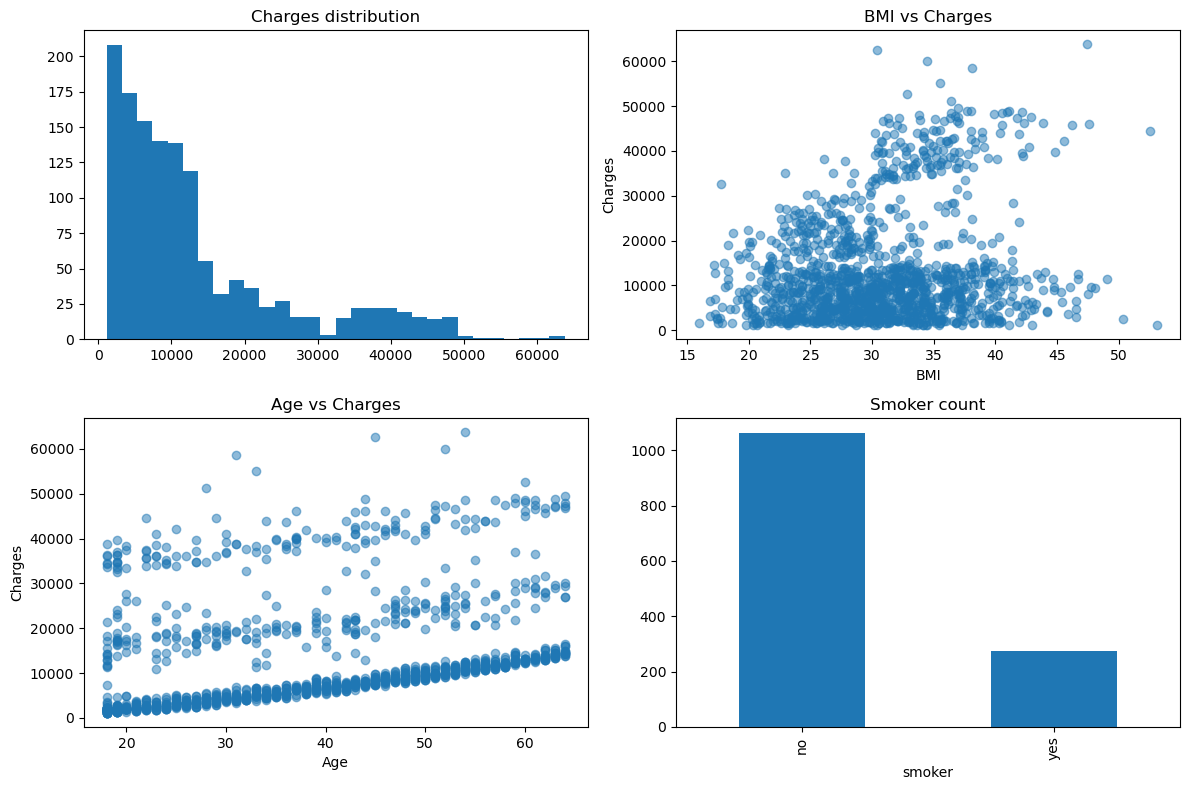

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].hist(df["charges"], bins=30)
axes[0, 0].set_title("Charges distribution")

axes[0, 1].scatter(df["bmi"], df["charges"], alpha=0.5)
axes[0, 1].set_title("BMI vs Charges")
axes[0, 1].set_xlabel("BMI")
axes[0, 1].set_ylabel("Charges")

axes[1, 0].scatter(df["age"], df["charges"], alpha=0.5)
axes[1, 0].set_title("Age vs Charges")
axes[1, 0].set_xlabel("Age")
axes[1, 0].set_ylabel("Charges")

df["smoker"].value_counts().plot(kind="bar", ax=axes[1, 1])
axes[1, 1].set_title("Smoker count")

plt.tight_layout()
plt.show()

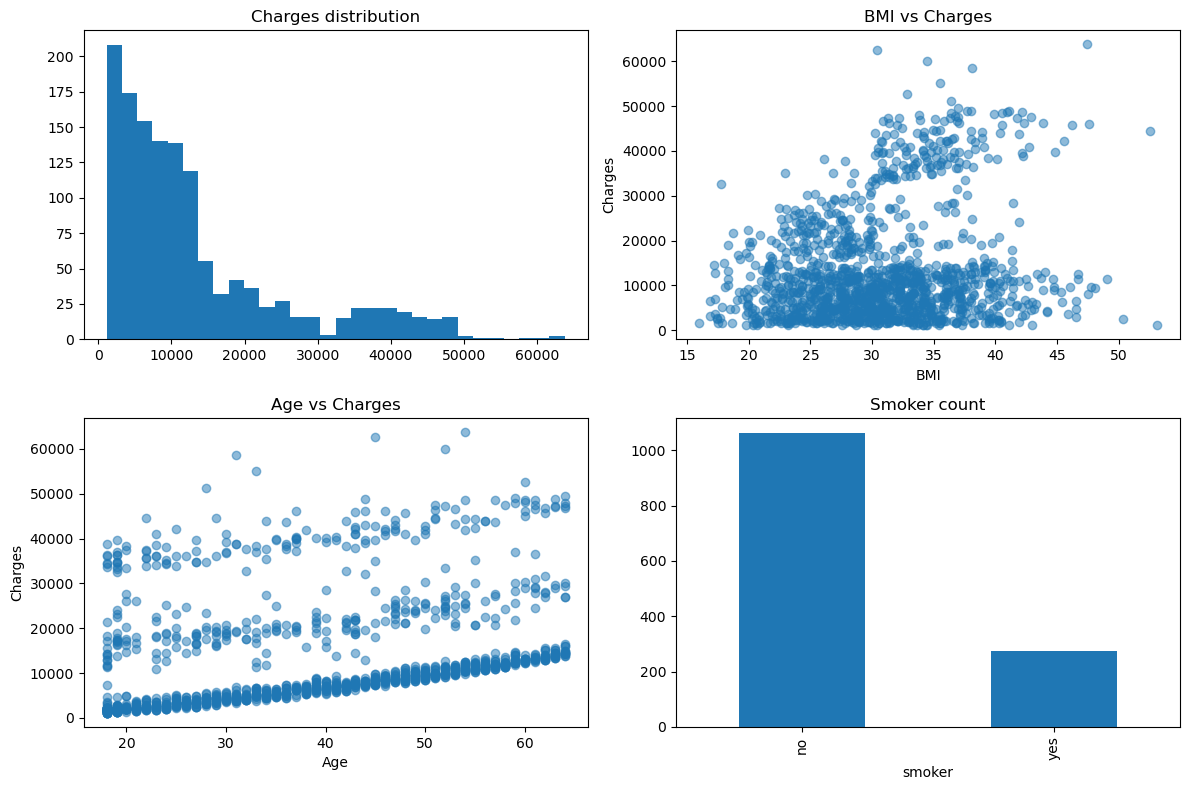

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].hist(df["charges"], bins=30)
axes[0, 0].set_title("Charges distribution")

axes[0, 1].scatter(df["bmi"], df["charges"], alpha=0.5)
axes[0, 1].set_title("BMI vs Charges")
axes[0, 1].set_xlabel("BMI")
axes[0, 1].set_ylabel("Charges")

axes[1, 0].scatter(df["age"], df["charges"], alpha=0.5)
axes[1, 0].set_title("Age vs Charges")
axes[1, 0].set_xlabel("Age")
axes[1, 0].set_ylabel("Charges")

df["smoker"].value_counts().plot(kind="bar", ax=axes[1, 1])
axes[1, 1].set_title("Smoker count")

plt.tight_layout()
plt.show()

In [6]:
X = df.drop(columns=["charges"])
y = df["charges"].astype(float)

numeric_features = ["age", "bmi", "children"]
categorical_features = ["sex", "smoker", "region"]

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

model = LinearRegression()

pipeline = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("regressor", model),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'bmi', 'children']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['sex', 'smoker', 'region'])],
                                   verbose_feature_names_out=False)),
                ('regressor', LinearRegression())])

In [7]:
y_pred = pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

MAE  : 4181.19
RMSE : 5796.28
R²   : 0.7836


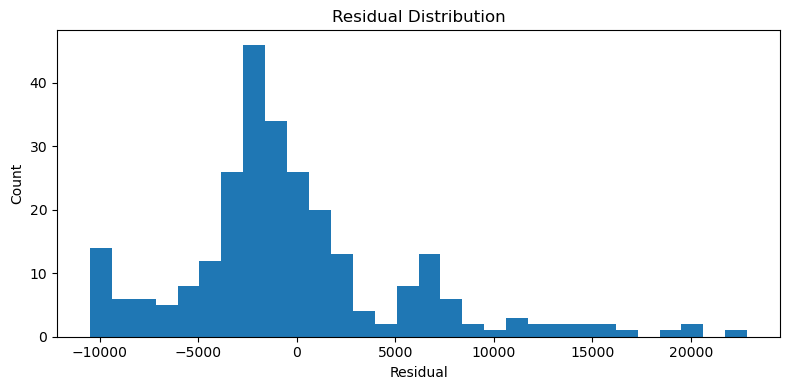

In [8]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 4))
plt.hist(residuals, bins=30)
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(DOCS_DIR / "residuals.png", dpi=150)
plt.show()

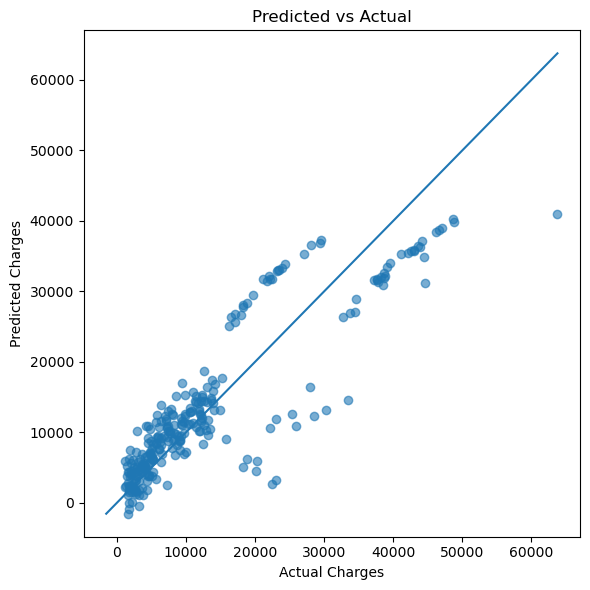

In [9]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.6)

low = min(y_test.min(), y_pred.min())
high = max(y_test.max(), y_pred.max())
plt.plot([low, high], [low, high])

plt.title("Predicted vs Actual")
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.tight_layout()
plt.savefig(DOCS_DIR / "pred_vs_actual.png", dpi=150)
plt.show()

In [10]:
pre = pipeline.named_steps["preprocess"]
reg = pipeline.named_steps["regressor"]

feature_names_out = list(pre.get_feature_names_out())

scaler = pre.named_transformers_["num"]
ohe = pre.named_transformers_["cat"]

model_bundle = {
    "meta": {
        "target": "charges",
        "test_size": 0.2,
        "random_state": 42,
        "metrics_test": {
            "MAE": float(mae),
            "RMSE": float(rmse),
            "R2": float(r2),
        },
    },
    "preprocess": {
        "numeric_features": numeric_features,
        "numeric_mean": scaler.mean_.tolist(),
        "numeric_scale": scaler.scale_.tolist(),
        "categorical_features": categorical_features,
        "categorical_categories": {
            feature: categories.tolist()
            for feature, categories in zip(categorical_features, ohe.categories_)
        },
        "feature_names_out": feature_names_out,
    },
    "model": {
        "intercept": float(reg.intercept_),
        "coef": reg.coef_.tolist(),
    },
}

with open(DOCS_DIR / "model.json", "w", encoding="utf-8") as f:
    json.dump(model_bundle, f, indent=2)

with open(DOCS_DIR / "metrics.json", "w", encoding="utf-8") as f:
    json.dump(model_bundle["meta"], f, indent=2)

print("Exported:")
print("-", DOCS_DIR / "model.json")
print("-", DOCS_DIR / "metrics.json")

Exported:
- docs\model.json
- docs\metrics.json


In [11]:
with open(DOCS_DIR / "model.json", "r", encoding="utf-8") as f:
    exported = json.load(f)

print(exported.keys())
print(exported["meta"])

dict_keys(['meta', 'preprocess', 'model'])
{'target': 'charges', 'test_size': 0.2, 'random_state': 42, 'metrics_test': {'MAE': 4181.194473753651, 'RMSE': 5796.284659276274, 'R2': 0.7835929767120722}}
